# HandTeX: Handwriting to LaTeX
Encoder-decoder models that convert handwritten math images to LaTeX strings.  
Dataset: [MathWriting-human](https://huggingface.co/datasets/deepcopy/MathWriting-human) (~230k samples).

In [27]:
import torch
import numpy as np
import pickle
import sys
from pathlib import Path
from PIL import Image
from datasets import load_dataset

sys.path.insert(0, "src/models")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ARTIFACTS = Path("src/artifacts")
print(f"Device: {DEVICE}")

Device: cuda


## Load Dataset

Test set: 7644 samples

Sample 0: \overline{X}+X_{\xi}


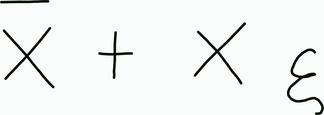


Sample 1: \frac{q}{A}=h_{o}(T_{o}-T_{s})


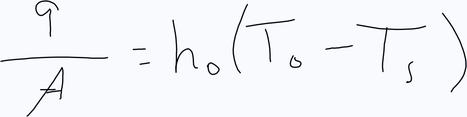


Sample 2: \langle a_{0},a_{1},...\rangle\in R^{\omega}


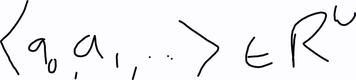

In [28]:
ds = load_dataset("deepcopy/MathWriting-human")
ds_test = ds["test"]
print(f"Test set: {len(ds_test)} samples")

# Show a few examples
for i in range(3):
    sample = ds_test[i]
    print(f"\nSample {i}: {sample['latex'][:80]}")
    display(sample["image"])

## Preprocessing & Tokenizer

In [35]:
def resize_pad_grayscale(img_pil, target=256, pad_value=255):
    """Resize keeping aspect ratio, pad to square."""
    img = img_pil.convert("L")
    w, h = img.size
    scale = target / max(w, h)
    new_w, new_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))
    img_rs = img.resize((new_w, new_h), resample=Image.BICUBIC)
    canvas = Image.new("L", (target, target), color=pad_value)
    canvas.paste(img_rs, ((target - new_w) // 2, (target - new_h) // 2))
    return canvas

# 92-vocab tokenizer
with open(ARTIFACTS / "lstm_tokenizer92.pkl", "rb") as f:
    tokenizer = pickle.load(f)
VS = max(tokenizer.word_index.values()) + 1
START, END = VS - 2, VS - 1
inv_vocab = {v: k for k, v in tokenizer.word_index.items()}

def decode(seq):
    return "".join(inv_vocab.get(t, "") for t in seq if t not in (0, START, END))

print(f"Vocab size: {VS}, START={START}, END={END}")

Vocab size: 92, START=90, END=91


In [36]:
def normalized_edit_distance(s1, s2):
    """Levenshtein distance normalized by max length."""
    if len(s1) == 0 and len(s2) == 0: return 0.0
    if len(s1) == 0 or  len(s2) == 0: return 1.0
    d = [[0] * (len(s2) + 1) for _ in range(len(s1) + 1)]
    for i in range(len(s1) + 1): d[i][0] = i
    for j in range(len(s2) + 1): d[0][j] = j
    for i in range(1, len(s1) + 1):
        for j in range(1, len(s2) + 1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            d[i][j] = min(d[i-1][j]+1, d[i][j-1]+1, d[i-1][j-1]+cost)
    return d[len(s1)][len(s2)] / max(len(s1), len(s2))

## Load Models

In [37]:
from vit_lora_lstm_attn import ViTLatexModelLoRA as LSTMModel

# LSTM LoRA r=16
lstm_92 = LSTMModel(vocab_size=VS, lora_r=16).to(DEVICE)
lstm_92.load_state_dict(torch.load(ARTIFACTS / "lstm_92vocab.pt", map_location=DEVICE, weights_only=False)["model"])
lstm_92.eval()
print("1/3 LSTM LoRA r=16 loaded")

# LSTM RSLoRA r=32
lstm_rslora = LSTMModel(vocab_size=VS, lora_r=32, lora_alpha=64, use_rslora=True).to(DEVICE)
lstm_rslora.load_state_dict(torch.load(ARTIFACTS / "lstm_rslora_r32.pt", map_location=DEVICE, weights_only=False)["model"])
lstm_rslora.eval()
print("2/3 LSTM RSLoRA r=32 loaded")

1/3 LSTM LoRA r=16 loaded
2/3 LSTM RSLoRA r=32 loaded


In [38]:
from importlib import import_module

# Transformer LoRA r=32
vit_trans = import_module("vit-transformer")
TransformerModel = vit_trans.ViTLatexModelLoRA

trans_92 = TransformerModel(vocab_size=VS, lora_r=32).to(DEVICE)
trans_92.load_state_dict(torch.load(ARTIFACTS / "dinov2_attn_lora-3.pt", map_location=DEVICE, weights_only=False)["model"])
trans_92.eval()
print("3/3 Transformer LoRA r=32 loaded")

3/3 Transformer LoRA r=32 loaded


## Evaluation on Test Set

In [39]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

N = 500  # number of test samples to evaluate

# Preprocess images
test_images = []
for i in range(N):
    img = resize_pad_grayscale(ds_test[i]["image"], target=256)
    img = np.array(img, dtype=np.float32) / 255.0
    test_images.append(img)
    if (i + 1) % 500 == 0 or i == N - 1:
        print(f"Preprocessed {i+1}/{N}", flush=True)
test_images = torch.tensor(np.array(test_images), dtype=torch.float32).unsqueeze(1)

# GT via 92-vocab tokenizer
gt_raw = [ds_test[i]["latex"] for i in range(N)]
seqs = tokenizer.texts_to_sequences(gt_raw)
seqs = [[START] + s + [END] for s in seqs]
gt_strings = [decode(t.tolist()) for t in pad_sequences(seqs, padding="post")]

print(f"Ready: {N} images")

Preprocessed 500/500
Ready: 500 images


In [40]:
models = [
    ("LSTM LoRA r=16",        lstm_92),
    ("LSTM RSLoRA r=32",      lstm_rslora),
    ("Transformer LoRA r=32", trans_92),
]

results = {}

for name, model in models:
    use_beam = hasattr(model, "generate_beam")
    exact = 0
    total_ed = 0.0

    print(f"\n{name} ({N} samples)")
    print("-" * 50)

    for i in range(N):
        img = test_images[i:i+1].repeat(1, 3, 1, 1).to(DEVICE)

        with torch.no_grad():
            if use_beam:
                pred_tokens = model.generate_beam(img, max_len=150, sos_idx=START, eos_idx=END, beam_size=5)
            else:
                pred_tokens = model.generate(img, max_len=150, sos_idx=START, eos_idx=END)

        pred = decode(pred_tokens)
        ed = normalized_edit_distance(pred, gt_strings[i])
        if pred == gt_strings[i]:
            exact += 1
        total_ed += ed

        if (i + 1) % 100 == 0 or i == N - 1:
            print(f"  [{i+1:>5}/{N}] exact={exact/(i+1):.2%}, avg ED={total_ed/(i+1):.4f}", flush=True)

    results[name] = {
        "exact_match": exact / N,
        "avg_edit_distance": total_ed / N,
    }


LSTM LoRA r=16 (500 samples)
--------------------------------------------------
  [  100/500] exact=35.00%, avg ED=0.1515
  [  200/500] exact=36.00%, avg ED=0.1428
  [  300/500] exact=36.67%, avg ED=0.1347
  [  400/500] exact=35.50%, avg ED=0.1409
  [  500/500] exact=36.00%, avg ED=0.1418

LSTM RSLoRA r=32 (500 samples)
--------------------------------------------------
  [  100/500] exact=40.00%, avg ED=0.1240
  [  200/500] exact=39.00%, avg ED=0.1203
  [  300/500] exact=39.00%, avg ED=0.1131
  [  400/500] exact=38.50%, avg ED=0.1183
  [  500/500] exact=38.00%, avg ED=0.1197

Transformer LoRA r=32 (500 samples)
--------------------------------------------------
  [  100/500] exact=37.00%, avg ED=0.1319
  [  200/500] exact=38.50%, avg ED=0.1285
  [  300/500] exact=38.67%, avg ED=0.1230
  [  400/500] exact=39.50%, avg ED=0.1250
  [  500/500] exact=40.00%, avg ED=0.1251


In [ ]:
# Transformer LoRA r=16
trans_r16_mod = import_module("vit-transformer-lora-r16")
TransR16 = trans_r16_mod.ViTLatexModelLoRA

trans_r16 = TransR16(vocab_size=VS, lora_r=16).to(DEVICE)
trans_r16.load_state_dict(torch.load(ARTIFACTS / "transformer_r16.pt", map_location=DEVICE, weights_only=False)["model"])
trans_r16.eval()

exact = 0
total_ed = 0.0
name = "Transformer LoRA r=16"

print(f"\n{name} ({N} samples)")
print("-" * 50)

for i in range(N):
    img = test_images[i:i+1].repeat(1, 3, 1, 1).to(DEVICE)

    with torch.no_grad():
        pred_tokens = trans_r16.generate(img, max_len=150, sos_idx=START, eos_idx=END)

    pred = decode(pred_tokens)
    ed = normalized_edit_distance(pred, gt_strings[i])
    if pred == gt_strings[i]:
        exact += 1
    total_ed += ed

    if (i + 1) % 100 == 0 or i == N - 1:
        print(f"  [{i+1:>5}/{N}] exact={exact/(i+1):.2%}, avg ED={total_ed/(i+1):.4f}", flush=True)

results[name] = {
    "exact_match": exact / N,
    "avg_edit_distance": total_ed / N,
}
print(f"\nFINAL: Exact={exact/N:.2%}, Avg ED={total_ed/N:.4f}")


Transformer LoRA r=16 (500 samples)
--------------------------------------------------
  [  100/500] exact=35.00%, avg ED=0.1402
  [  200/500] exact=37.50%, avg ED=0.1321
  [  300/500] exact=37.00%, avg ED=0.1297
  [  400/500] exact=36.50%, avg ED=0.1313
  [  500/500] exact=38.20%, avg ED=0.1296

FINAL: Exact=38.20%, Avg ED=0.1296


## Results

In [43]:
print(f"{'Model':<35} {'Exact Match':>12} {'Avg Edit Dist':>14}")
print("-" * 63)
for name, metrics in results.items():
    print(f"{name:<35} {metrics['exact_match']:>11.2%} {metrics['avg_edit_distance']:>14.4f}")

Model                                Exact Match  Avg Edit Dist
---------------------------------------------------------------
LSTM LoRA r=16                           36.00%         0.1418
LSTM RSLoRA r=32                         38.00%         0.1197
Transformer LoRA r=32                    40.00%         0.1251
Transformer LoRA r=16                    38.20%         0.1296
